In [1]:
%matplotlib notebook

import os

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

import multiprocessing as mp

import numpy as np
import pandas as pd
from tqdm import tqdm
from pprint import pprint
from glob import glob

import pandas as pd

import mdtraj as md

from sklearn.decomposition import PCA, FastICA

## Load MD and Crystal data

In [18]:
ATOM_SELECTION = '(element != H) and is_protein and (resi < 303) and (resi > 1)'

def load_pdbs(glob_pattern):
    
    crystals = None
    crystal_chis = []

    first = True
    files_to_load = sorted(glob(glob_pattern))
    
    for pdb in tqdm(files_to_load):

        try:
            
            trj = md.load_pdb(pdb)
            idx = trj.top.select(ATOM_SELECTION)
            trj = trj.atom_slice(idx)

            chi_atoms, chi = md.compute_chi1(trj)
            crystal_chis.extend(chi)

            if first:
                chi_idx = [ trj.topology.atom(int(a)).residue.index for a in chi_atoms[:,0] ]
                first = False

            idx = trj.top.select('name == CA')
            trj = trj.atom_slice(idx)

            if crystals:
                crystals = crystals.join(trj, check_topology=False)
            else:
                crystals = trj

        except Exception as exptn:
            print(trj.xyz.shape)
            print(crystals.xyz.shape)
            print("something went wrong", pdb, exptn)

    crystals = crystals.center_coordinates()
    crystal_chis = np.array(crystal_chis)
    
    return crystals, crystal_chis

In [19]:
SUBSAMPLE     = 10 # for MD simulation, 1 = 1 ns
XTAL_S_FACTOR = 35.0

In [20]:
crystals, crystal_chis = load_pdbs('../../allostery/selected_dataset_archive_2023-01-14/pdb/*.pdb')

100%|██████████| 1146/1146 [05:07<00:00,  3.73it/s]


In [21]:
# each dcd file is 1000 frames with 1ns spacing between frames

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
md_files = sorted(glob(prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'))

top_path = prefix + '/system_nowat.pdb'

md_sim = None
md_chis = []

for f in tqdm(md_files):

    t = md.load(f, top=top_path)[::SUBSAMPLE]

    idx = t.top.select(ATOM_SELECTION)
    t   = t.atom_slice(idx)
    
    _, chis = md.compute_chi1(t)
    md_chis.extend(chis)

    idx = t.top.select('name == CA')
    t   = t.atom_slice(idx)

    if md_sim == None:
        md_sim = t
    else:
        md_sim += t

md_sim = md_sim.center_coordinates()
md_chis = np.array(md_chis)

100%|██████████| 100/100 [00:57<00:00,  1.73it/s]


In [22]:
prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/'
diamond, diamond_chis = load_pdbs(prefix + '*.pdb')

 57%|█████▋    | 60/105 [00:11<00:09,  4.98it/s]

(1, 299, 3)
(59, 301, 3)
something went wrong /asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/Mpro-x1187_0.pdb Number of atoms in self (301) is not equal to number of atoms in other


100%|██████████| 105/105 [00:20<00:00,  5.04it/s]


In [23]:
ensemble_pdb_path = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/ensemble/SARS-COV-mpro_ensemble_1_nowat.pdb'
ensemble, ensemble_chis = load_pdbs(ensemble_pdb_path)

100%|██████████| 1/1 [00:07<00:00,  7.79s/it]


In [24]:
vagabond_pdb_path = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/ensemble/ensemble_69_superimposed.pdb'
vagabond, vagabond_chis = load_pdbs(vagabond_pdb_path)

100%|██████████| 1/1 [00:08<00:00,  8.53s/it]


In [25]:
print(crystals.xyz.shape, crystal_chis.shape)
print(md_sim.xyz.shape,   md_chis.shape)
print(diamond.xyz.shape,  diamond_chis.shape)
print(ensemble.xyz.shape, ensemble_chis.shape)
print(vagabond.xyz.shape, vagabond_chis.shape)

(1146, 301, 3) (1146, 259)
(10000, 301, 3) (10000, 259)
(104, 301, 3) (105,)
(72, 301, 3) (72, 259)
(131, 301, 3) (131, 259)


In [26]:
active_site_residues = np.array([41, 49, 143, 144, 145, 163, 164, 165, 166, 167, 187, 188, 189, 190, 191, 192]) - 1

## Compute Ca covariance tensor

In [27]:
def isotropic_cov(xyz, norm=False):
    
    # we want X.T * X summed over last dim
    S = ( np.cov(xyz[:,:,0].T) + np.cov(xyz[:,:,1].T) + np.cov(xyz[:,:,2].T) ) / 3.0
    
    if norm:
        factor = S.std()
        print('norm:', 1.0/factor)
        S /= factor
    
    return S


def abs_cov(xyz):
    
    n_data  = xyz.shape[0]
    n_atoms = xyz.shape[1]

    xyz_centered = xyz - np.mean(xyz, axis=0)[None,:,:]
    assert xyz_centered.shape == xyz.shape, xyz_centered.shape
    S = np.einsum('aik,ajl->ijkl', xyz_centered, xyz_centered)
    S = S / float(xyz.shape[0] - 1)
    
    S = np.sum(np.abs(S), axis=(2,3))
    
    return S


def bootstrap_iso_cov(xyz, n_samples=10, debug=False):
    
    if debug:
        sigmas = np.zeros([n_samples, xyz.shape[1], xyz.shape[1]])
    
    # running variance estimate
    # https://www.johndcook.com/blog/standard_deviation/
    
    for k in range(n_samples):
        
        smpl_idx = np.random.randint(0, xyz.shape[0], size=xyz.shape[0])
        smpl = xyz[smpl_idx,:,:]
        
        x = isotropic_cov(smpl)
        
        if debug:
            sigmas[k] = x
        
        if k == 0:
            M_km1 = x
            S_km1 = np.zeros_like(x)
        else:
            M_k = M_km1 + (x-M_km1) / (k+1)
            S_k = S_km1 + (x-M_km1) * (x-M_k)
            M_km1 = M_k
            S_km1 = S_k
        
    if debug:
        resi = 55
        print(np.sqrt(S_k / k)[resi,resi])
        print(np.std(sigmas[:,resi,resi]))
    
    return np.sqrt(S_k / k)

In [28]:
S_xtal = isotropic_cov(crystals.xyz) * XTAL_S_FACTOR
S_md   = isotropic_cov(md_sim.xyz)
S_dmnd = isotropic_cov(diamond.xyz)  * XTAL_S_FACTOR
S_ensb = isotropic_cov(ensemble.xyz) * XTAL_S_FACTOR
S_vaga = isotropic_cov(vagabond.xyz) * XTAL_S_FACTOR

In [29]:
err_S_xtal = bootstrap_iso_cov(crystals.xyz, n_samples=1000) * XTAL_S_FACTOR

<IPython.core.display.Javascript object>


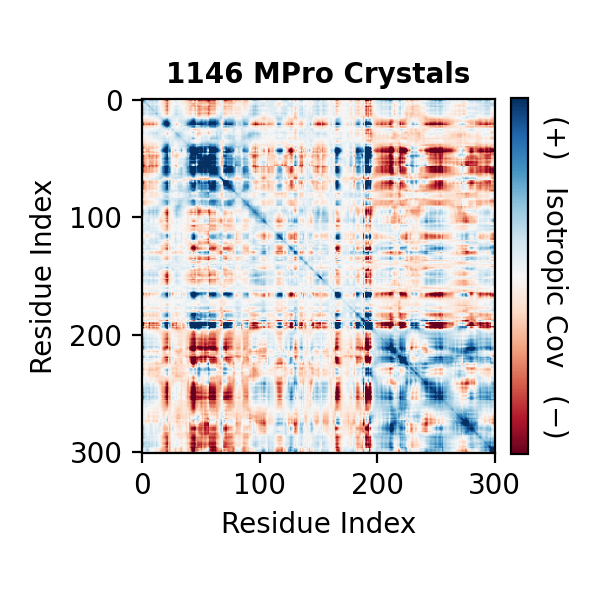

<IPython.core.display.Javascript object>


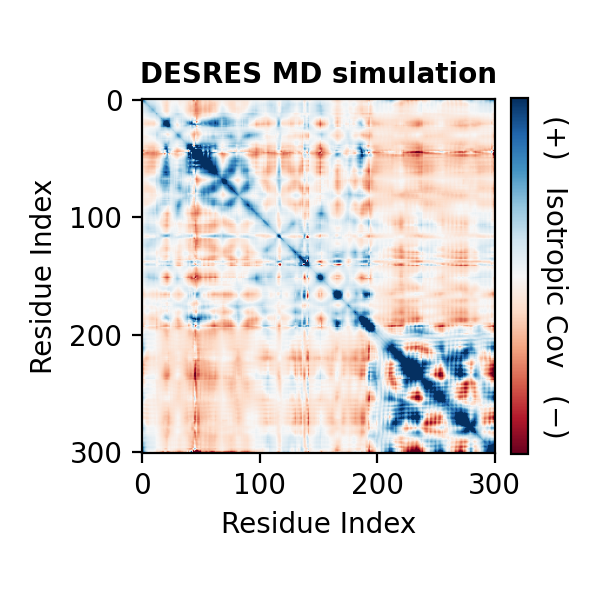

<IPython.core.display.Javascript object>


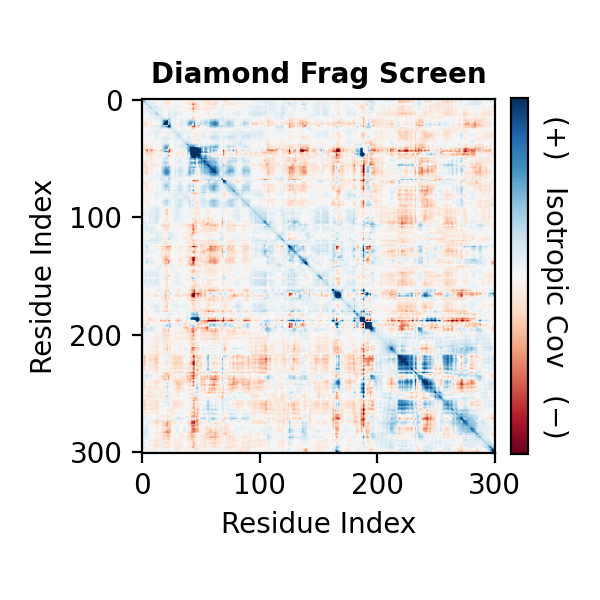

<IPython.core.display.Javascript object>


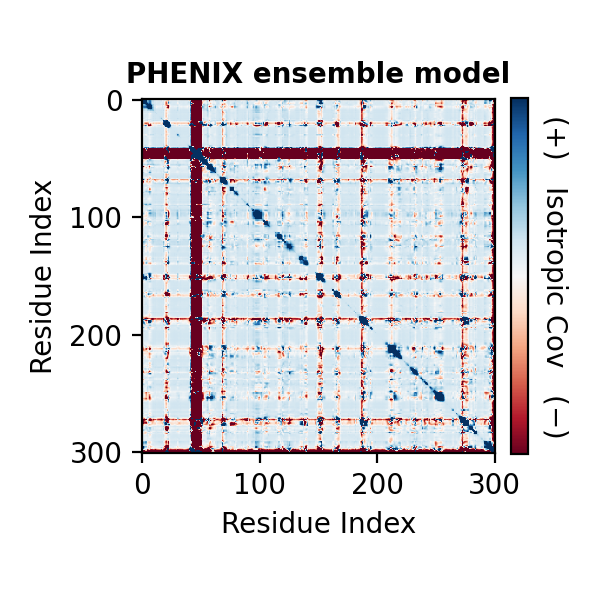

<IPython.core.display.Javascript object>


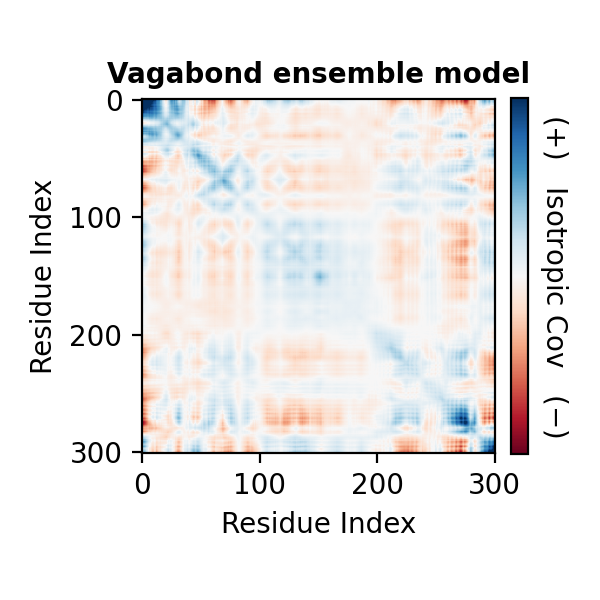

In [44]:
scale = 0.003 # how much to zoom colorbar
ticks = np.arange(0, crystals.xyz.shape[1], 100)
cmap = 'RdBu'


figsize = (3,3)

fig = plt.figure(figsize=figsize)
ax1 = plt.subplot(111)

ax1.set_title('%d MPro Crystals' % crystals.n_frames, 
              fontweight='bold', fontsize=10)
im = ax1.imshow(S_xtal, cmap=cmap, 
                vmin=-scale, vmax=scale)

ax1.set_xticks(ticks)
ax1.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax1.set_yticks(ticks)
ax1.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax1.set_xlabel('Residue Index')
ax1.set_ylabel('Residue Index')

cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_ticks([])
cbar.set_label('$(+)$   Isotropic Cov   $(-)$', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('./figures/covariance_matrices/cov_xtal_ensemble.pdf')
plt.show()

# ------

fig = plt.figure(figsize=figsize)
ax2 = plt.subplot(111)

ax2.set_title('DESRES MD simulation', 
              fontweight='bold', fontsize=10)
im = ax2.imshow(S_md[:S_xtal.shape[0],:S_xtal.shape[1]], cmap=cmap, 
                vmin=-scale, vmax=scale)

ax2.set_xticks(ticks)
ax2.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax2.set_yticks(ticks)
ax2.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax2.set_xlabel('Residue Index')
ax2.set_ylabel('Residue Index')

cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_ticks([])
cbar.set_label('$(+)$   Isotropic Cov   $(-)$', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('./figures/covariance_matrices/cov_md.pdf')

plt.show()

# ------

fig = plt.figure(figsize=figsize)
ax3 = plt.subplot(111)

ax3.set_title('Diamond Frag Screen', 
              fontweight='bold', fontsize=10)
im = ax3.imshow(S_dmnd, cmap=cmap, 
           vmin=-scale, vmax=scale)

ax3.set_xticks(ticks)
ax3.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax3.set_yticks(ticks)
ax3.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax3.set_xlabel('Residue Index')
ax3.set_ylabel('Residue Index')

cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_ticks([])
cbar.set_label('$(+)$   Isotropic Cov   $(-)$', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('./figures/covariance_matrices/cov_dmnd_ensemble.pdf')
plt.show()

# ------

fig = plt.figure(figsize=figsize)
ax4 = plt.subplot(111)

ax4.set_title('PHENIX ensemble model', 
              fontweight='bold', fontsize=10)
im = ax4.imshow(S_ensb, cmap=cmap, 
           vmin=-scale, vmax=scale)

ax4.set_xticks(ticks)
ax4.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax4.set_yticks(ticks)
ax4.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax4.set_xlabel('Residue Index')
ax4.set_ylabel('Residue Index')

cbar = plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
cbar.set_ticks([])
cbar.set_label('$(+)$   Isotropic Cov   $(-)$', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('./figures/covariance_matrices/cov_phenix_ensemble.pdf')
plt.show()

# ------

fig = plt.figure(figsize=figsize)
ax5 = plt.subplot(111)

ax5.set_title('Vagabond ensemble model', 
              fontweight='bold', fontsize=10)
im = ax5.imshow(S_vaga, cmap=cmap, 
           vmin=-scale, vmax=scale)

ax5.set_xticks(ticks)
ax5.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax5.set_yticks(ticks)
ax5.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax5.set_xlabel('Residue Index')
ax5.set_ylabel('Residue Index')

cbar = plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)
cbar.set_ticks([])
cbar.set_label('$(+)$   Isotropic Cov   $(-)$', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('./figures/covariance_matrices/cov_vagabond_ensemble.pdf')
plt.show()

<IPython.core.display.Javascript object>


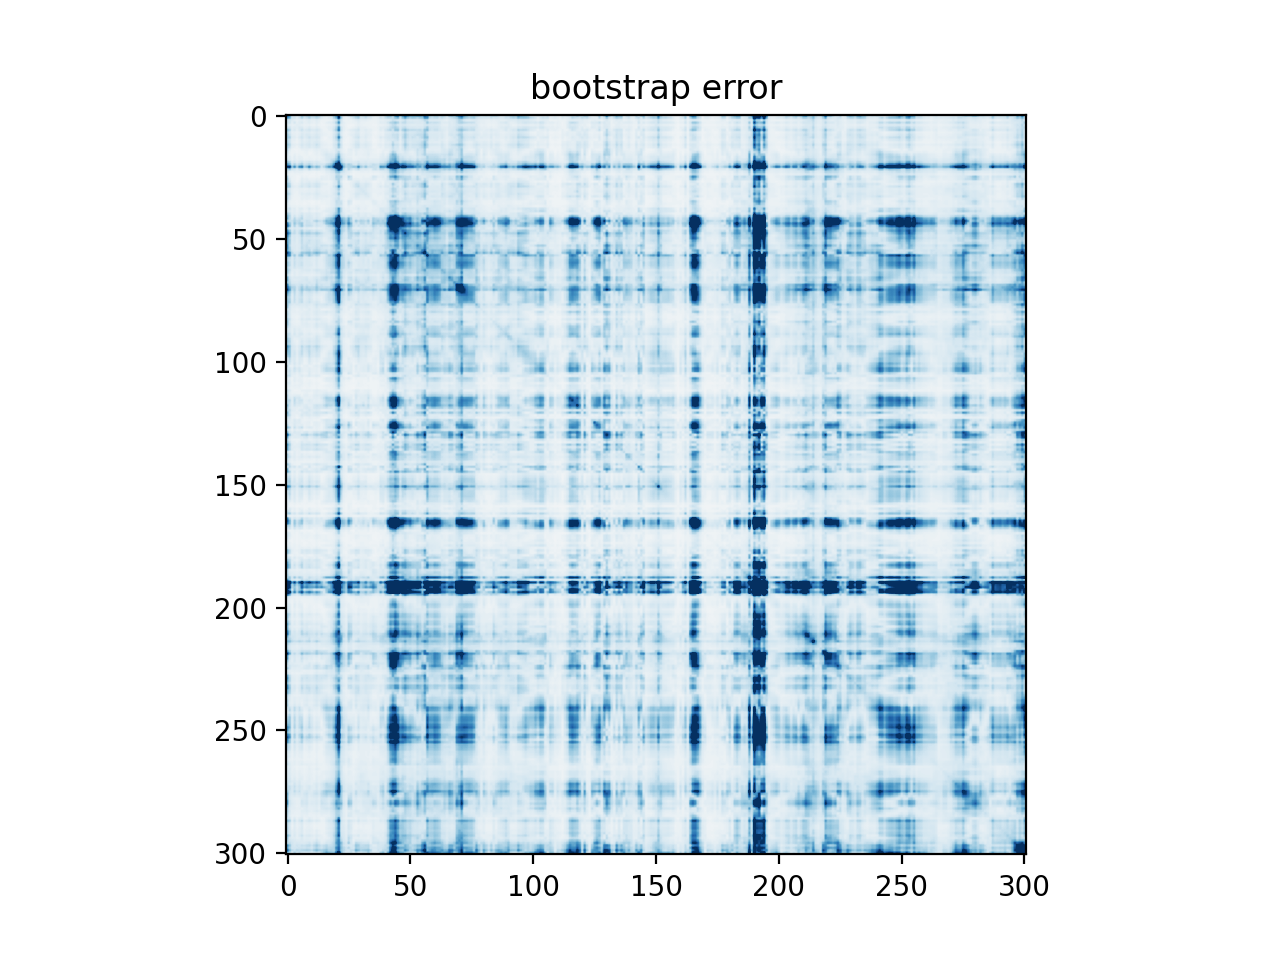

In [43]:
plt.figure()
plt.title('bootstrap error')
plt.imshow(err_S_xtal, cmap=cmap, vmin=-scale/10, vmax=scale/10)
plt.show()

In [33]:
mu_xtal  = np.abs(S_xtal[active_site_residues,:]).mean(0)
std_xtal = np.abs(S_xtal[active_site_residues,:]).std(0)

err_mu_xtal = np.sqrt(np.mean(np.square(err_S_xtal[active_site_residues,:]), axis=0)) # 1-sigma

mu_md  = np.abs(S_md[active_site_residues,:S_xtal.shape[0]]).mean(0)
std_md = np.abs(S_md[active_site_residues,:S_xtal.shape[0]]).std(0)

mu_dmnd  = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).mean(0)
std_dmnd = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).std(0)

mu_vaga  = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).mean(0)
std_vaga = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).std(0)

# ----------------------------------------------------------------------------

# np.savetxt('saved/ca_corr.txt', mu_xtal)
# np.savetxt('saved/ca_corr_md.txt', mu_md)

## View correlation projected on active site

<IPython.core.display.Javascript object>


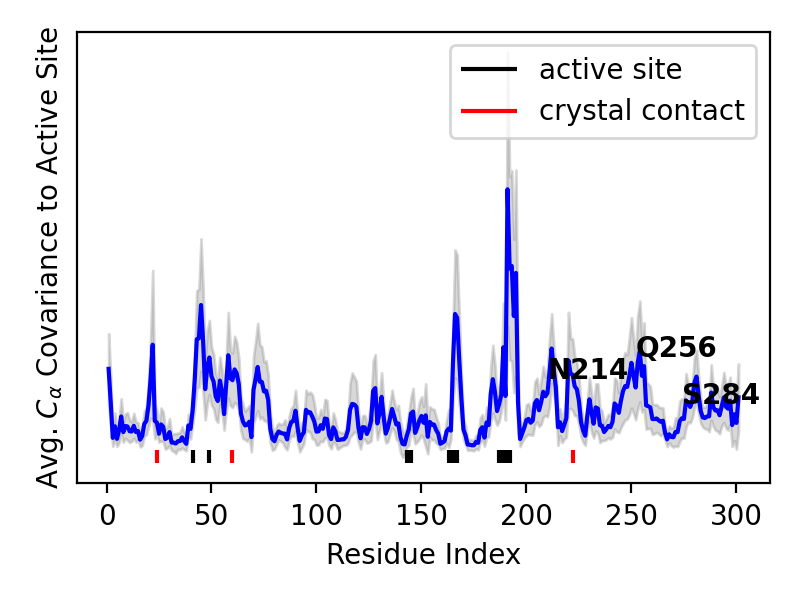

In [36]:
offset = 0.005
chi_offset = 200

residues = list(crystals.top.residues)
asr_names = [ residues[a].name for a in active_site_residues ]

# ----------------------------------------------------------------------------

res_idx = np.arange(S_xtal.shape[0])+1


plt.figure(figsize=(4,3))

ax1 = plt.subplot(111)

ax1.plot(res_idx, mu_xtal, color='b')

ax1.fill_between(res_idx, mu_xtal - err_mu_xtal * 3, mu_xtal + err_mu_xtal * 3, 
                alpha=0.3, color='grey')

ax1.set_xlabel(r'Residue Index')
ax1.set_ylabel(r'Avg. $C_\alpha$ Covariance to Active Site')
ax1.set_yticks([])

# crystal contacts
cont = ax1.vlines(24, -0.0002, 0.0001, color='r')
ax1.vlines(60, -0.0002, 0.0001, color='r')
ax1.vlines(222, -0.0002, 0.0001, color='r')

# active site residues
for r in active_site_residues:
    act = ax1.vlines(r+1, -0.0002, 0.0001)

# interesting
x_shift = -0
y_shift = 0.0003
ax1.text(210 + x_shift, mu_xtal[213] + y_shift - 0.0001, 'N214', weight='bold')
ax1.text(252 + x_shift, mu_xtal[255] + y_shift - 0.0001, 'Q256', weight='bold')
ax1.text(274 + x_shift, mu_xtal[283] + y_shift, 'S284', weight='bold')
    
plt.legend([act, cont], ['active site', 'crystal contact'])
    
plt.tight_layout()
plt.savefig('figures/cov_to_active.pdf')
plt.show()

Compare with MD simulation

<IPython.core.display.Javascript object>


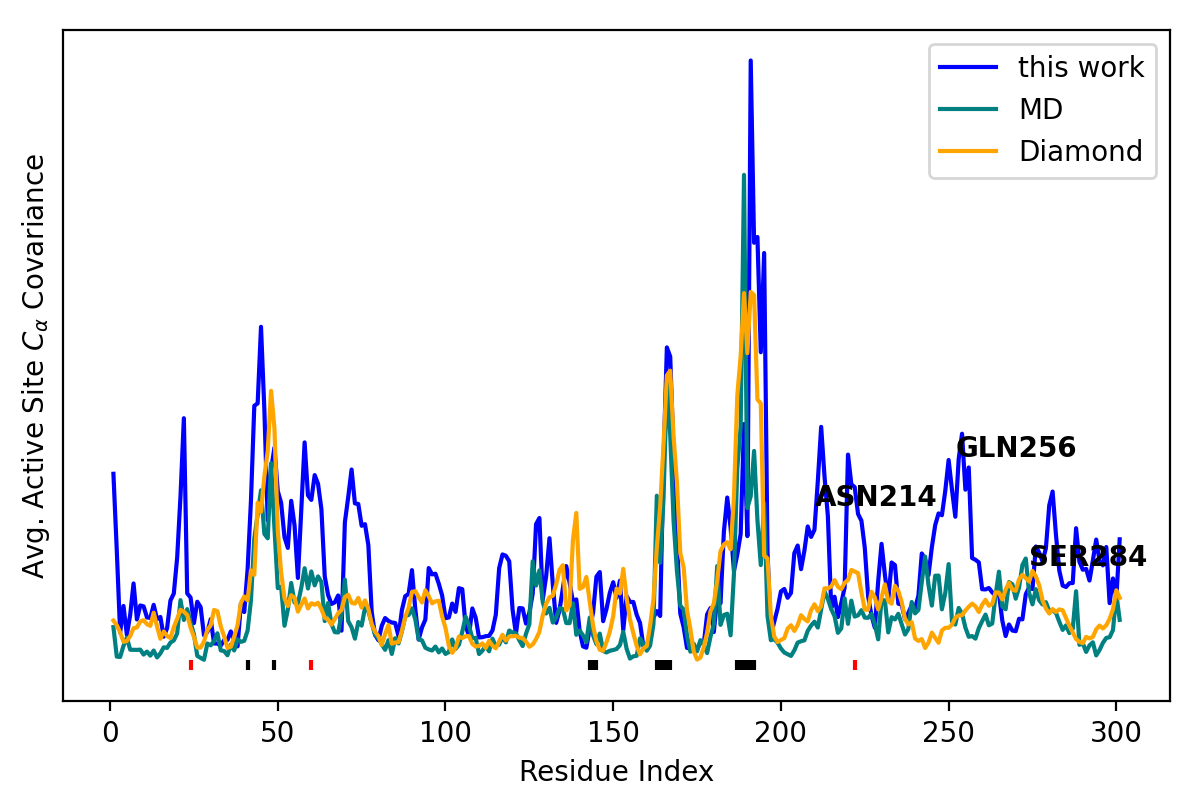

In [38]:
plt.figure(figsize=(6,4))

ax1 = plt.subplot(111)

p1 = ax1.plot(res_idx, mu_xtal, color='b')
p2 = ax1.plot(res_idx, mu_dmnd, color='teal')
p3 = ax1.plot(res_idx, mu_md, color='orange')
#ax1.plot(res_idx[:-2], mu_vaga, color='orange')

ax1.set_xlabel('Residue Index')
ax1.set_ylabel(r'Avg. Active Site $C_\alpha$ Covariance')
ax1.set_yticks([])

# crystal contacts
cont = ax1.vlines(24, -0.0000, 0.0001, color='r')
ax1.vlines(60, -0.0000, 0.0001, color='r')
ax1.vlines(222, -0.0000, 0.0001, color='r')

# active site residues
for r in active_site_residues:
    act = ax1.vlines(r+1, -0.0000, 0.0001)

# interesting
ax1.text(210, mu_xtal[213] + 0.0001, 'ASN214', weight='bold')
ax1.text(252, mu_xtal[255] + 0.0001, 'GLN256', weight='bold')
ax1.text(274, mu_xtal[283] + 0.0002, 'SER284', weight='bold')
    
#plt.legend([act, cont], ['active site', 'crystal contact'])
plt.legend(['this work', 'MD', 'Diamond'])
 
plt.savefig('figures/screen_md_diamond_corr.pdf')
plt.tight_layout()
plt.show()

## absolute correlation (ie include off diagonal elements)

In [41]:
S_xtal_abs = abs_cov(crystals.xyz)

mu_xtal_abs  = np.abs(S_xtal_abs[active_site_residues,:]).mean(0)
std_xtal_abs = np.abs(S_xtal_abs[active_site_residues,:]).std(0)

<IPython.core.display.Javascript object>


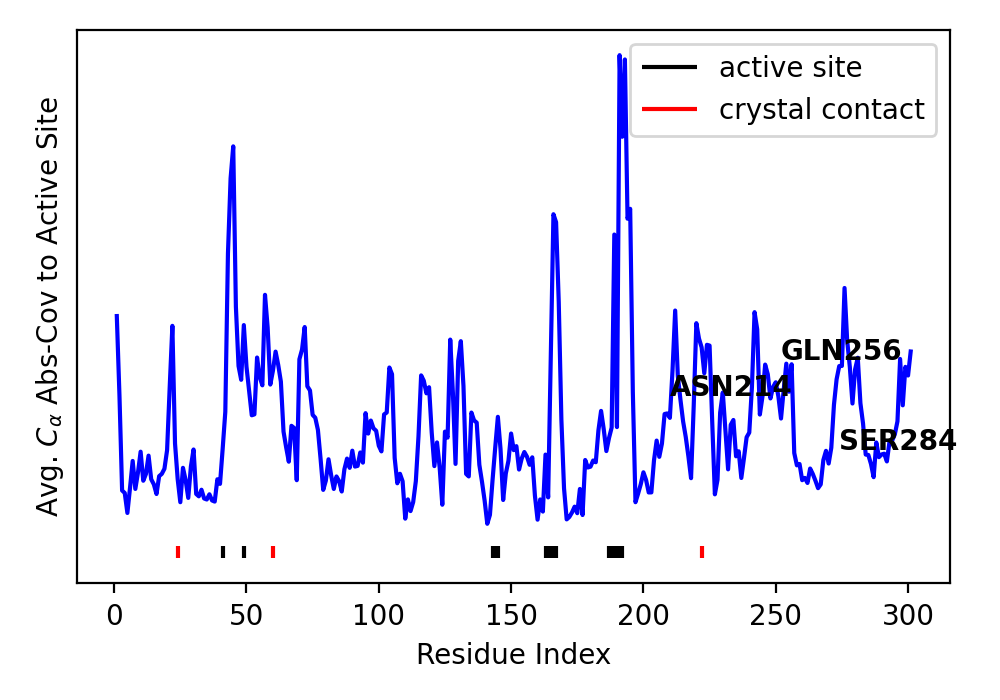

In [45]:
offset = 0.005
chi_offset = 200

residues = list(crystals.top.residues)
asr_names = [ residues[a].name for a in active_site_residues ]

# ----------------------------------------------------------------------------

res_idx = np.arange(S_xtal.shape[0])+1


plt.figure(figsize=(5,3.5))

ax1 = plt.subplot(111)

ax1.plot(res_idx, mu_xtal_abs, color='b')

# ax1.fill_between(res_idx, mu_xtal - err_mu_xtal * 3, mu_xtal + err_mu_xtal * 3, 
#                 alpha=0.3, color='grey')

ax1.set_xlabel(r'Residue Index')
ax1.set_ylabel(r'Avg. $C_\alpha$ Abs-Cov to Active Site')
ax1.set_yticks([])

# crystal contacts
cont = ax1.vlines(24, -0.0000, 0.00003, color='r')
ax1.vlines(60, -0.0000, 0.00003, color='r')
ax1.vlines(222, -0.0000, 0.00003, color='r')

# active site residues
for r in active_site_residues:
    act = ax1.vlines(r+1, -0.0000, 0.00003)

# interesting
ax1.text(210, mu_xtal_abs[213] + 0.00001, 'ASN214', weight='bold')
ax1.text(252, mu_xtal_abs[255] + 0.00001, 'GLN256', weight='bold')
ax1.text(274, mu_xtal_abs[283] + 0.00001, 'SER284', weight='bold')
    
plt.legend([act, cont], ['active site', 'crystal contact'])
    
plt.tight_layout()
#plt.savefig('figures/cov_to_active_including_off_diagonal.pdf')
plt.show()